# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).

---

## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)


A) Potential dataset: SIPRI Military Expenditure Database - https://milex.sipri.org/sipri
B) Brief overview of dataset: The SIPRI Military Expenditure Database contains consistent time series on the military spending of countries for the period 1949–2024.
It includes key variables that help to understand the periodic history of arms policy: 
- Military expenditure in local currency (current prices)
- Military expenditure in current and constant US dollars
- Military expenditure as a percentage of GDP
- Military expenditure as a share of government spending
- Military expenditure per capita
- Year (calendar and/or financial year)
- Country/region identifiers
The data is structured as a panel dataset.
The number of rows depends on the selected countries and time period (160 countries and 1945-2024 give a large number of rows).
The initial idea of the project is to conduct a case study comparison of the war-neighbouring countries. It involves two triggers, such as the Russian invasion of Ukraine and the Iraq war. The analysis represents the behaviour of the above-named war-neighbouring countries in terms of military expenditures after the trigger was pulled. Simply said,  how the variable “being a war neighbour” affects spending (% of GDP) using basic regression.


        Country  Year  Military_Spending
0           NaN   NaN                NaN
1        Africa   NaN                NaN
2  North Africa   NaN                NaN
3       Algeria   NaN                NaN
4         Libya   NaN                NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14861 entries, 0 to 14860
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            14784 non-null  object 
 1   Year               14668 non-null  float64
 2   Military_Spending  8302 non-null   float64
dtypes: float64(2), object(1)
memory usage: 348.4+ KB
None
               Year  Military_Spending
count  14668.000000       8.302000e+03
mean    1986.500000       4.111433e-01
std       21.938159       5.119755e+00
min     1949.000000       1.715000e-07
25%     1967.750000       1.181881e-02
50%     1986.500000       1.907080e-02
75%     2005.250000       3.208430e-02
max     2024.000000       1.010000e

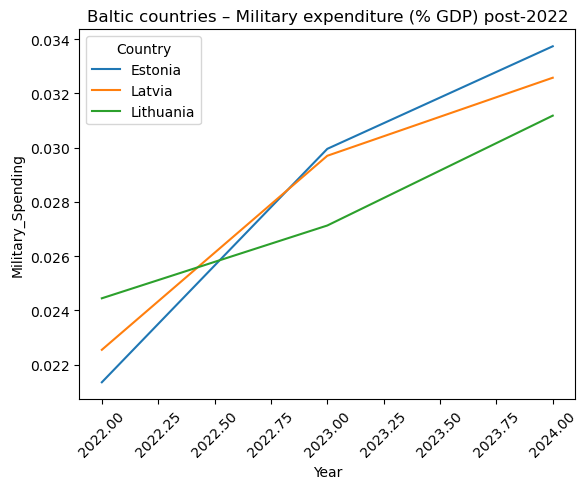

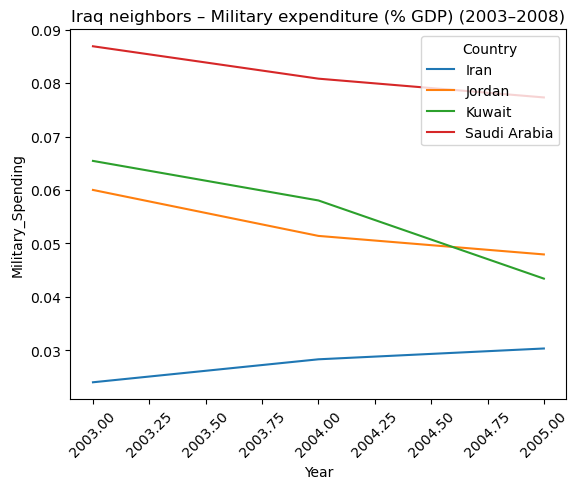

In [13]:
#C
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Excel file
df = pd.read_excel(
    "/Users/romanklymenko/Downloads/SIPRI-Milex-data-1949-2024_2.xlsx",
    sheet_name="Share of GDP",
    header=5
)

# Reshape to long format
df_long = df.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Military_Spending"
)

# Convert data types
df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
df_long["Military_Spending"] = pd.to_numeric(df_long["Military_Spending"], errors="coerce")

#explunatory analysis
print(df_long.head())
print(df_long.info())
print(df_long.describe())
print(df_long.isnull().sum())

# Case 1: Baltic countries post-2022
baltics_post = df_long[
    (df_long["Country"].isin(["Estonia", "Latvia", "Lithuania"])) &
    (df_long["Year"] >= 2022)
]

plt.figure()
sns.lineplot(data=baltics_post, x="Year", y="Military_Spending", hue="Country")
plt.title("Baltic countries – Military expenditure (% GDP) post-2022")
plt.xticks(rotation=45)
plt.show()

# Case 2: Iraq neighbours (2003–2005)

iraq_neighbors_post = df_long[
    (df_long["Country"].isin(["Turkey", "Iran", "Saudi Arabia", "Jordan", "Kuwait"])) &
    (df_long["Year"] >= 2003) &
    (df_long["Year"] <= 2005)
]

plt.figure()
sns.lineplot(data=iraq_neighbors_post, x="Year", y="Military_Spending", hue="Country")
plt.title("Iraq neighbors – Military expenditure (% GDP) (2003–2008)")
plt.xticks(rotation=45)
plt.show()

## Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [7]:
import os
from dotenv import load_dotenv
load_dotenv("/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/.env")
api_key = os.getenv("MY_API_KEY")
print(api_key[:5] + "...")

aa153...


# Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [18]:
import requests
import os
import pandas as pd
from dotenv import load_dotenv
#A
# IMPORT API KEY 
load_dotenv("/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/.env")
api_key = os.getenv("MY_API_KEY")
#SETTING PARAMETERS
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
all_data = []

for ticker in tickers:
    url = "http://api.marketstack.com/v1/eod"

    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 100
    }

    response = requests.get(url, params=params)
    data = response.json()

    if "data" in data:
        for record in data["data"]:
            record["symbol"] = ticker
            all_data.append(record)

# B: DATAFRAME 
df = pd.DataFrame(all_data)

# print first 5 rows
print("First 5 rows:")
print(df.head())

# C: SUMMARY STATS 
# group by stock
summary = df.groupby("symbol")["close"].agg(["mean", "min", "max", "std"])

# return calculation (first vs last trading day)
returns = {}

for symbol in df["symbol"].unique():
    stock_df = df[df["symbol"] == symbol].sort_values("date")

    first_close = stock_df.iloc[0]["close"]
    last_close = stock_df.iloc[-1]["close"]

    return_pct = ((last_close - first_close) / first_close) * 100
    returns[symbol] = return_pct

returns_df = pd.DataFrame.from_dict(returns, orient="index", columns=["return_pct"])

# combine stats + returns
final_df = summary.join(returns_df)

print("\nSummary statistics + returns:")
print(final_df)

# best and worse results 
best_stock = returns_df["return_pct"].idxmax()
worst_stock = returns_df["return_pct"].idxmin()

print("\nBest performing stock:", best_stock)
print("Worst performing stock:", worst_stock)

First 5 rows:
     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000  
2  2026-03-27T00:0

In [18]:
import requests
import os
import pandas as pd
from dotenv import load_dotenv

# IMPORT API KEY 
load_dotenv("/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/.env")
api_key = os.getenv("MY_API_KEY")
#SETTING PARAMETERS
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
all_data = []

for ticker in tickers:
    url = "http://api.marketstack.com/v1/eod"

    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 100
    }

    response = requests.get(url, params=params)
    data = response.json()

    if "data" in data:
        for record in data["data"]:
            record["symbol"] = ticker
            all_data.append(record)

# B: DATAFRAME 
df = pd.DataFrame(all_data)

# print first 5 rows
print("First 5 rows:")
print(df.head())

# C: SUMMARY STATS 
# group by stock
summary = df.groupby("symbol")["close"].agg(["mean", "min", "max", "std"])

# return calculation (first vs last trading day)
returns = {}

for symbol in df["symbol"].unique():
    stock_df = df[df["symbol"] == symbol].sort_values("date")

    first_close = stock_df.iloc[0]["close"]
    last_close = stock_df.iloc[-1]["close"]

    return_pct = ((last_close - first_close) / first_close) * 100
    returns[symbol] = return_pct

returns_df = pd.DataFrame.from_dict(returns, orient="index", columns=["return_pct"])

# combine stats + returns
final_df = summary.join(returns_df)

print("\nSummary statistics + returns:")
print(final_df)

# best and worse results 
best_stock = returns_df["return_pct"].idxmax()
worst_stock = returns_df["return_pct"].idxmin()

print("\nBest performing stock:", best_stock)
print("Worst performing stock:", worst_stock)

First 5 rows:
     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000  
2  2026-03-27T00:0

### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

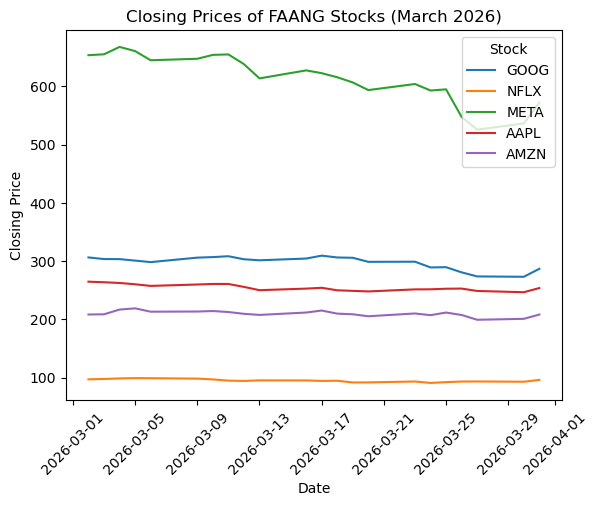

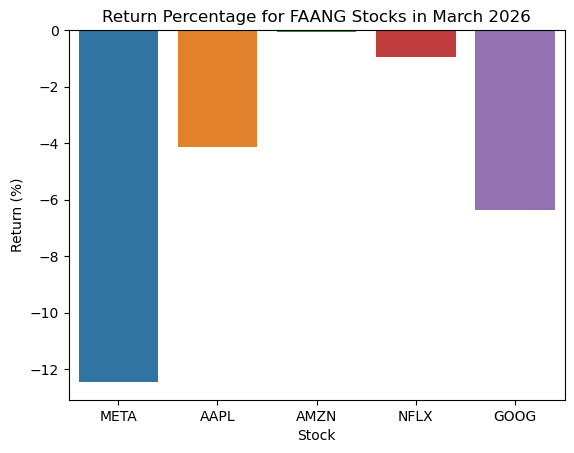

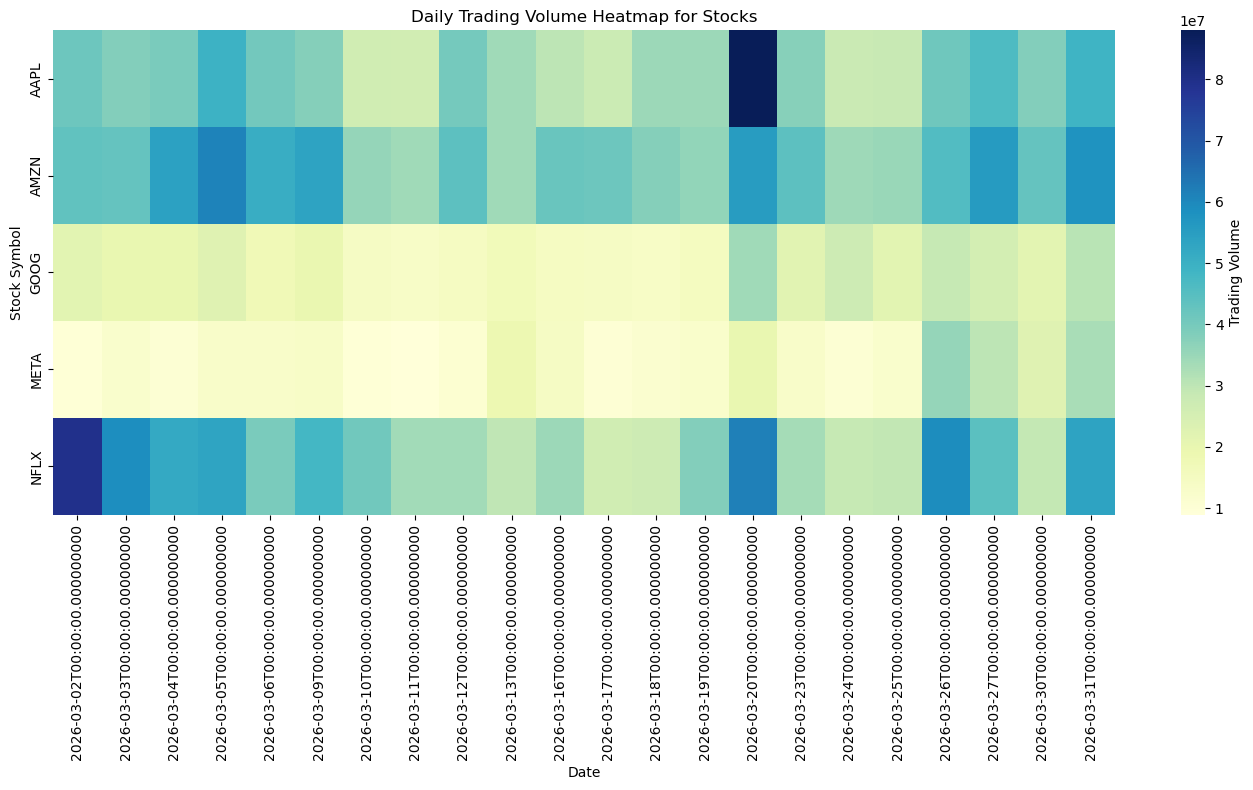

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Sort values 
df = df.sort_values(by='date')
#A LINE CHART
sns.lineplot(
    data=df,
    x='date',
    y='close',
    hue='symbol'
)

plt.title('Closing Prices of FAANG Stocks (March 2026)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title='Stock')
plt.xticks(rotation=45)

plt.show()

#B BAR CHART
if 'date' in returns_df.columns:
    df_march = returns_df[(returns_df['date'] >= '2026-03-01') & (returns_df['date'] <= '2026-03-31')]
# If returns_df is indexed by date:
elif isinstance(returns_df.index, pd.DatetimeIndex):
    df_march = returns_df[(returns_df.index >= '2026-03-01') & (returns_df.index <= '2026-03-31')]
# If returns_df doesn't have dates but is related to symbols in df:
else:
# Get symbols for March 2026 from df
    march_symbols = df[(df['date'] >= '2026-03-01') & (df['date'] <= '2026-03-31')]['symbol'].unique()
    df_march = returns_df[returns_df.index.isin(march_symbols)]
#Setting bar chart parameters
sns.barplot(
    data=df_march,
    x=df_march.index,  
    y='return_pct',
    hue=df_march.index  
)
#Setting a visual settings 
plt.title('Return Percentage for FAANG Stocks in March 2026')
plt.xlabel('Stock')
plt.ylabel('Return (%)')

plt.show()
#C HEATMAP
volume_pivot = df.pivot_table(
    index='symbol',
    columns='date',
    values='volume',
)
# Create the heatmap
plt.figure(figsize=(14, 8))  #Setting appropriate size
sns.heatmap(
    volume_pivot,
    cmap='YlGnBu',  
    cbar_kws={'label': 'Trading Volume'}
)

plt.title('Daily Trading Volume Heatmap for Stocks')
plt.xlabel('Date')
plt.ylabel('Stock Symbol')

# Adjust layout to make room for labels
plt.tight_layout()

plt.show()

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [8]:
import requests
import os
import pandas as pd
from dotenv import load_dotenv
load_dotenv("/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/.env")
api_key = os.getenv("MY_API_KEY")
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
all_data = []

for ticker in tickers:
    url = "http://api.marketstack.com/v1/eod"

    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 100
    }

    response = requests.get(url, params=params)
    data = response.json()

    if "data" in data:
        for record in data["data"]:
            record["symbol"] = ticker
            all_data.append(record)


df = pd.DataFrame(all_data)

summary = df.groupby("symbol")["close"].agg(["mean", "min", "max", "std"])


returns = {}

for symbol in df["symbol"].unique():
    stock_df = df[df["symbol"] == symbol].sort_values("date")

    first_close = stock_df.iloc[0]["close"]
    last_close = stock_df.iloc[-1]["close"]

    return_pct = ((last_close - first_close) / first_close) * 100
    returns[symbol] = return_pct

returns_df = pd.DataFrame.from_dict(returns, orient="index", columns=["return_pct"])


final_df = summary.join(returns_df)



 
best_stock = returns_df["return_pct"].idxmax()
worst_stock = returns_df["return_pct"].idxmin()



#A EXPORTING TO JSON
import json 
import pandas as pd

with open(
    "/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/Exports/stockdata.json", "w") as f:
    json.dump(all_data, f, indent= 4)
#B EXPORTING TO CSV
df.to_csv("/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/Exports/stockdata.csv" , index = False)
#C LOADING BACK JSON AND CSV
import pandas as pd
import json
with open("/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/Exports/stockdata.json", "r") as f:
    loaded_json_data = json.load(f)
    
# Convert JSON data to DataFrame for easier comparison
df_from_json = pd.DataFrame(loaded_json_data)

# Load CSV data
df_from_csv = pd.read_csv("/Users/romanklymenko/Desktop/RomanKlymenko/assignments/assignment1/Exports/stockdata.csv")

# Print the first five rows of each
print("Original DataFrame (first 5 rows):")
print(df.head())
print("\nDataFrame loaded from JSON (first 5 rows):")
print(df_from_json.head())
print("\nDataFrame loaded from CSV (first 5 rows):")
print(df_from_csv.head())



Original DataFrame (first 5 rows):
     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000

### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [10]:
import pandas as pd
import sqlite3
#A) Connecting database
conn = sqlite3.connect('northwind.db') 
df = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(df['name'])

#B Setting parameters for query 
df1 = pd.read_sql_query("""
SELECT ProductName, UnitPrice, UnitsInStock 
FROM Products
WHERE UnitPrice > 30 
""", conn)
print(df1)

#C  JOINING tables 

df2 = pd.read_sql_query("""
SELECT 
c.CompanyName, 
o.OrderID,
o.OrderDate, 
o.ShipCountry, 
(od.UnitPrice * od.Quantity) AS LineTotal
FROM Customers c 
JOIN Orders o ON  c.CustomerID = o.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
""", conn)
print(df2)

0               Categories
1          sqlite_sequence
2     CustomerCustomerDemo
3     CustomerDemographics
4                Customers
5                Employees
6      EmployeeTerritories
7            Order Details
8                   Orders
9                 Products
10                 Regions
11                Shippers
12               Suppliers
13             Territories
Name: name, dtype: object
                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      

### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

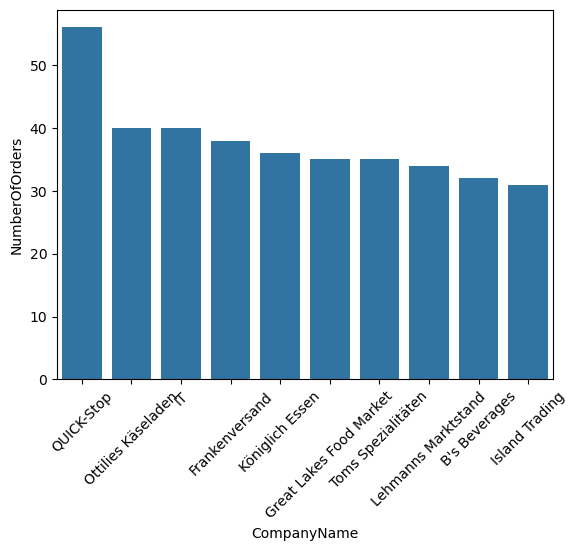

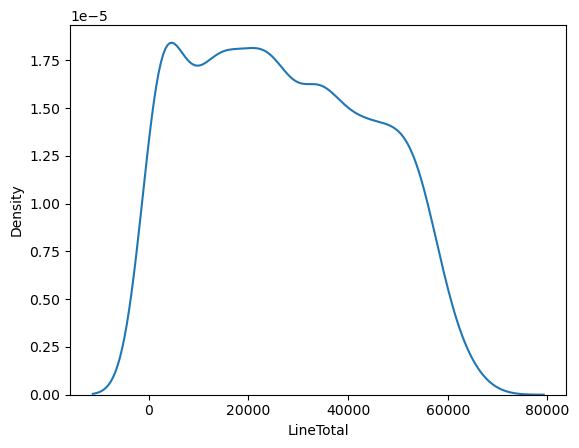

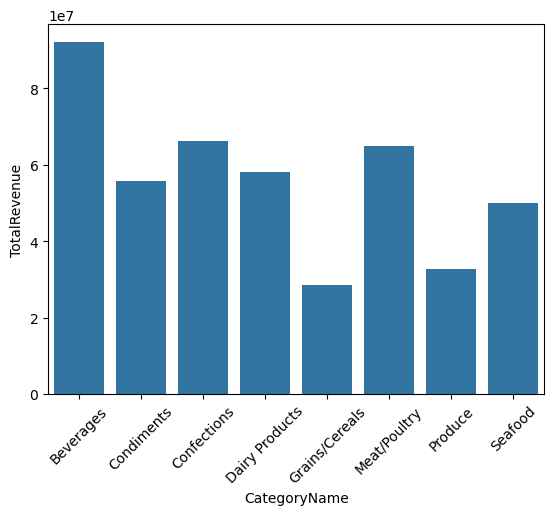

In [17]:
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt
#A BAR PLOT
df = df2[['CompanyName', 'OrderID']]
df = df.drop_duplicates()
orders_per_customer = df.groupby('CompanyName')['OrderID'].count() # Creating new variable (grouping by)
orders_per_customer = orders_per_customer.reset_index()
orders_per_customer.columns = ['CompanyName', 'NumberOfOrders']
top10 = orders_per_customer.sort_values('NumberOfOrders', ascending = False).head(10) #Sorting top 10 
#Setting visual 
sns.barplot(
    data=top10,
    x ='CompanyName',  
    y ='NumberOfOrders',
)
plt.xticks(rotation=45)
plt.show()
#B KDE PLOT
df3 = df2[[ 'LineTotal' , 'OrderDate']] #Select nedeed columns
daily_total = df3.groupby('OrderDate')['LineTotal'].sum() #Group by
sns.kdeplot(data=daily_total) #Setting visual
plt.show()
#C
df = pd.read_sql_query("""
SELECT 
    cat.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
INNER JOIN Products p ON od.ProductID = p.ProductID
INNER JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
""", conn)
#Setting visual 
sns.barplot(
    data = df,
    x = 'CategoryName',  
    y = 'TotalRevenue'
)
plt.xticks(rotation=45)
plt.show()

### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [36]:
import pandas as pd
import time

# A) SQL

products = pd.read_sql_query("SELECT * FROM Products", conn)
categories = pd.read_sql_query("SELECT * FROM Categories", conn)

print(products.head())
print(categories.head())

# B) INNER JOIN (PANDAS)

df_joined = pd.merge(products, categories, on="CategoryID", how="inner")
print(df_joined.head())

# C) SPEED COMPARISON

# SQL VERSION
start_sql = time.time()

df_sql = pd.read_sql_query("""
SELECT 
    cat.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
""", conn)

sql_time = time.time() - start_sql


#PANDAS VERSION 
start_pd = time.time()

order_details = pd.read_sql_query(
    'SELECT OrderID, ProductID, UnitPrice, Quantity FROM "Order Details"', conn
)
products = pd.read_sql_query(
    "SELECT ProductID, CategoryID FROM Products", conn
)
categories = pd.read_sql_query(
    "SELECT CategoryID, CategoryName FROM Categories", conn
)

df = order_details.merge(products, on="ProductID", how="inner")
df = df.merge(categories, on="CategoryID", how="inner")

df["LineTotal"] = df["UnitPrice"] * df["Quantity"]

df_pd = df.groupby("CategoryName")["LineTotal"].sum().reset_index()

pandas_time = time.time() - start_pd

# RESULT
print("\n COMPARISON ")
print("SQL time:", sql_time)
print("Pandas time:", pandas_time)

if sql_time < pandas_time:
    print("Conclusion: SQL is faster")
else:
    print("Conclusion: Pandas is faster")

   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3            0  
4            1  
  

### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [40]:
import pandas as pd

# A Wide to long (melt)
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

wide_long = pd.melt(
    wide_data,
    id_vars=["store"],
    var_name="quarter",   # FIXED
    value_name="sales"
)

print("\nLONG FORMAT")
print(wide_long)


# B Long to wide
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

long_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).reset_index()

print("\nWIDE FORMAT")
print(long_wide)


# C back to original

wide_restored = wide_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

print("\nRESTORED WIDE DATA")
print(wide_restored)

long_restored = long_wide.melt(
    id_vars=["month"],
    var_name="product",
    value_name="units_sold"
)

print("\nRESTORED LONG DATA")
print(long_restored)


LONG FORMAT
       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500

WIDE FORMAT
product month  Laptop  Phone
0         Feb      50    110
1         Jan      45    120
2         Mar      55    130

RESTORED WIDE DATA
quarter     store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0        Helsinki     12000     13500     11800     15000
1         Tampere      8500      9100      8800     10200
2           Turku      9200      9800     10100     11500

RESTORED LONG DATA
  month product  units_sold
0   Feb  Laptop          50
1   Jan  Laptop          45
2   Mar  Laptop          55
3   Feb   Phone         110
4   Jan   Phone         120
5   Mar   Phone         130
